Day Animal: 498 images
Day Civilian: 499 images
Day Soldier: 406 images
Night Animal: 421 images


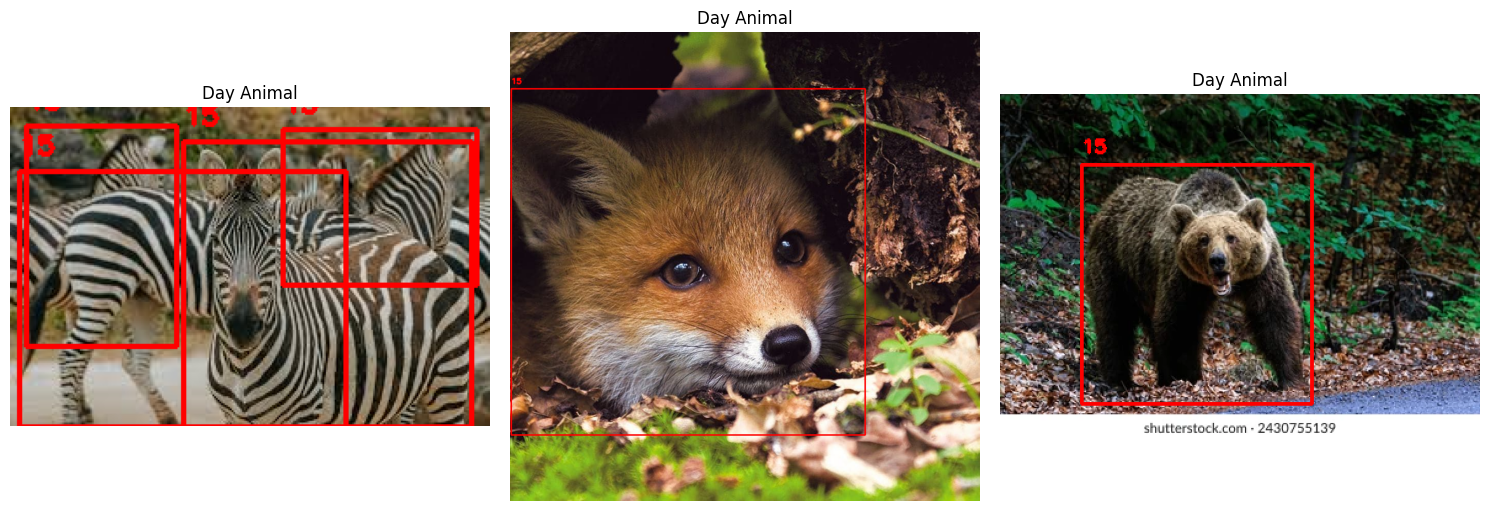

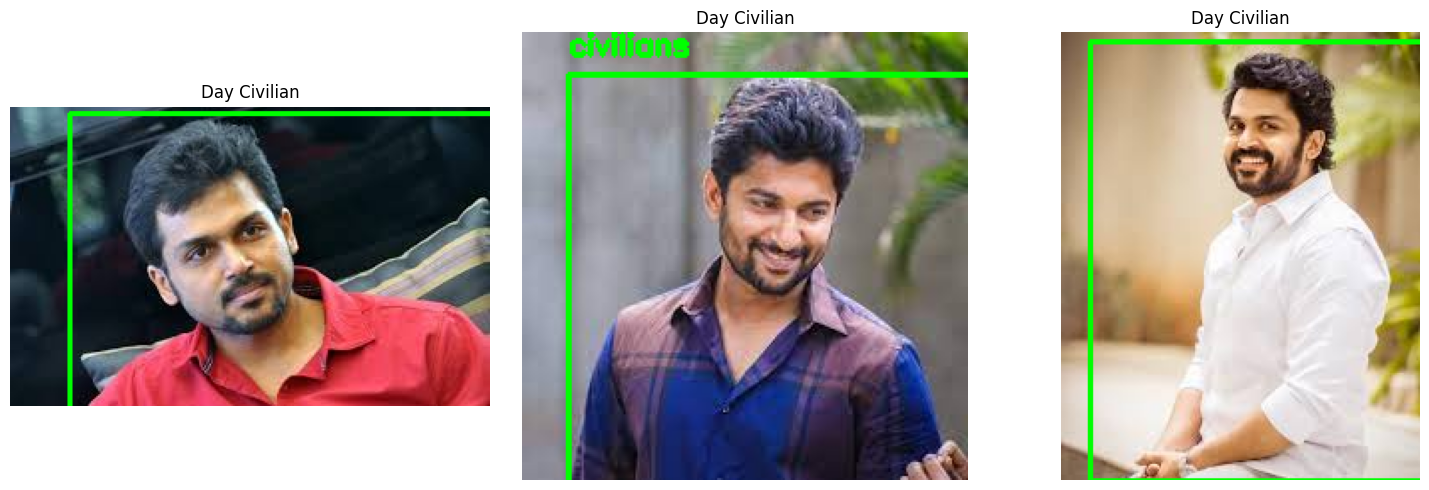

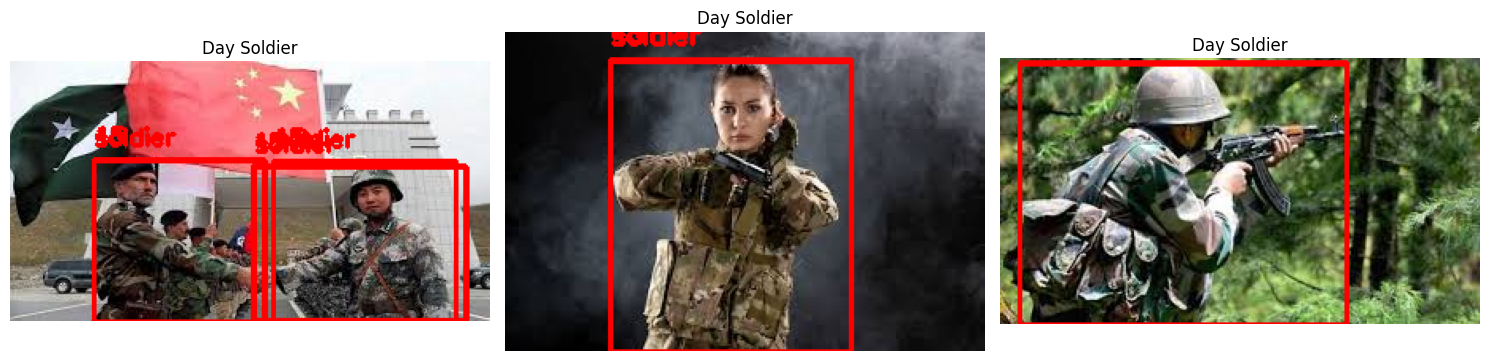

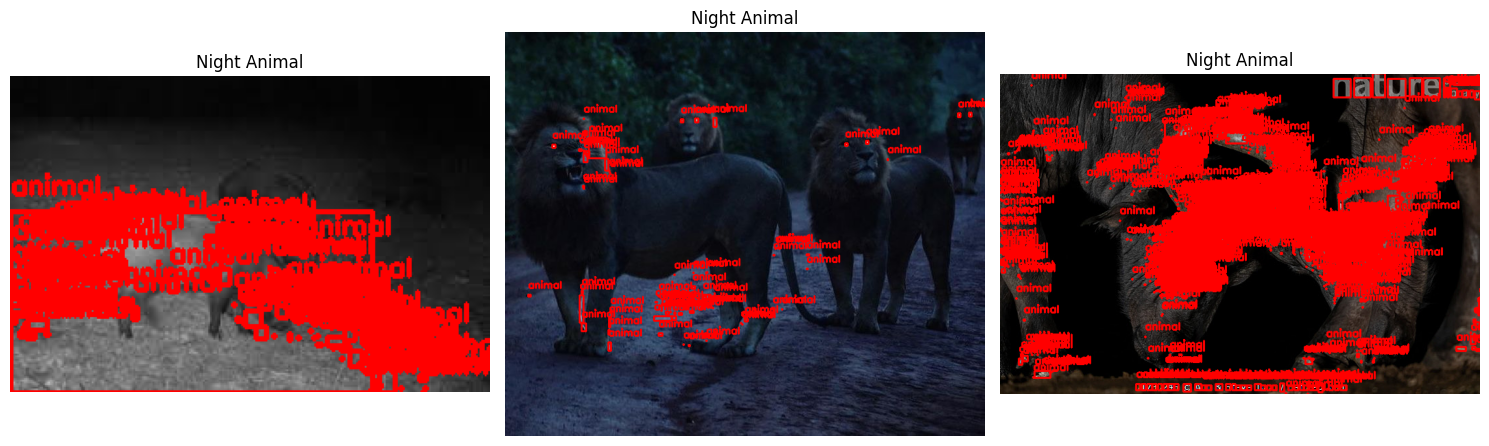

In [1]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import xml.etree.ElementTree as ET

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = float(bndbox.find('xmin').text)
        ymin = float(bndbox.find('ymin').text)
        xmax = float(bndbox.find('xmax').text)
        ymax = float(bndbox.find('ymax').text)
        
        width = xmax - xmin
        height = ymax - ymin
        x_center = xmin + width/2
        y_center = ymin + height/2
        
        boxes.append({'class': class_name, 'coords': [x_center, y_center, width, height]})
    return boxes

def parse_txt(txt_path):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_name = parts[0]
                coords = [float(x) for x in parts[1:5]]
                boxes.append({'class': class_name, 'coords': coords})
    return boxes

def detect_objects_simple(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_height, img_width = img.shape[:2]
    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        x_center = (x + w / 2) / img_width
        y_center = (y + h / 2) / img_height
        width = w / img_width
        height = h / img_height
        boxes.append({'class': 'animal', 'coords': [x_center, y_center, width, height]})
    return boxes

def load_dataset(path, category):
    images, labels = [], []
    img_paths = glob(os.path.join(path, '**', '*.jpg'), recursive=True)
    img_paths.extend(glob(os.path.join(path, '**', '*.png'), recursive=True))
    
    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
            boxes = []
            if category == 'animal' and 'Day' in path:
                txt_path = os.path.join('/kaggle/input/defence-dataset/Dataset/Classification/Day/animal/txt', os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt'))
                boxes = parse_txt(txt_path)
            elif category == 'soldier':
                xml_path = img_path.replace('images', 'labels/xml').replace('.jpg', '.xml').replace('.png', '.xml')
                boxes.extend(parse_xml(xml_path) if os.path.exists(xml_path) else [])
                txt_path = img_path.replace('images', 'labels/text').replace('.jpg', '.txt').replace('.png', '.txt')
                boxes.extend(parse_txt(txt_path))
            elif category == 'animal' and 'Night' in path:
                boxes = detect_objects_simple(img)
            else:
                txt_path = img_path.replace('images', 'labels').replace('.jpg', '.txt').replace('.png', '.txt')
                boxes = parse_txt(txt_path)
            
            labels.append(boxes if boxes else None)
    return images, labels

def draw_boxes(img, boxes):
    img_copy = img.copy()
    img_height, img_width = img.shape[:2]
    
    colors = {'animal': (255, 0, 0), 'civilians': (0, 255, 0), 'soldiers': (0, 0, 255)}
    
    for box in boxes:
        coords = box['coords']
        class_name = box['class'].lower()
        color = colors.get(class_name, (255, 0, 0))
        
        x_center, y_center, width, height = coords
        if x_center <= 1.0:
            x_center *= img_width
            y_center *= img_height
            width *= img_width
            height *= img_height
        
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_copy, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_copy

def display_samples(images, labels, category, num_samples=3):
    if not images:
        print(f"No images found for {category}")
        return
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    indices = np.random.choice(len(images), num_samples)
    
    for i, idx in enumerate(indices):
        img = images[idx]
        if labels[idx]:
            img = draw_boxes(img, labels[idx])
        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

base_path = '/kaggle/input/defence-dataset/Dataset/Classification'

datasets = {
    "Day Animal": load_dataset(os.path.join(base_path, 'Day/animal'), 'animal'),
    "Day Civilian": load_dataset(os.path.join(base_path, 'Day/human/civilian'), 'civilian'),
    "Day Soldier": load_dataset(os.path.join(base_path, 'Day/human/soldier'), 'soldier'),
    "Night Animal": load_dataset(os.path.join(base_path, 'Night/animal'), 'animal')
}

for name, (images, _) in datasets.items():
    print(f"{name}: {len(images)} images")

for name, (images, labels) in datasets.items():
    display_samples(images, labels, name)


Loaded 1600 images for training.


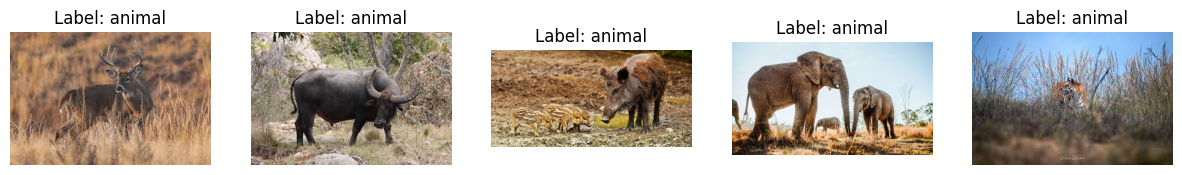

preprocessor_config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Some weights of EfficientNetForImageClassification were not initialized from the model checkpoint at google/efficientnet-b0 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 1280]) in the checkpoint and torch.Size([3, 1280]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cpu
Epoch 1/50 | Batch 0 | Loss: 1.0688
Epoch 1/50 | Batch 5 | Loss: 1.0218
Epoch 1/50 | Batch 10 | Loss: 0.9523
Epoch 1/50 | Batch 15 | Loss: 0.8899
Epoch 1/50 | Batch 20 | Loss: 0.9144
Epoch 1/50 | Batch 25 | Loss: 0.8881
Epoch 1/50 | Batch 30 | Loss: 0.7975
Epoch 1/50 | Batch 35 | Loss: 0.7938
Epoch 1/50 | Batch 40 | Loss: 0.6763
Epoch 1/50 | Batch 45 | Loss: 0.6772
Epoch 1 completed. Avg Loss: 0.8470
Epoch 2/50 | Batch 0 | Loss: 0.6109
Epoch 2/50 | Batch 5 | Loss: 0.6077
Epoch 2/50 | Batch 10 | Loss: 0.5717
Epoch 2/50 | Batch 15 | Loss: 0.5524
Epoch 2/50 | Batch 20 | Loss: 0.5751
Epoch 2/50 | Batch 25 | Loss: 0.5853
Epoch 2/50 | Batch 30 | Loss: 0.5693
Epoch 2/50 | Batch 35 | Loss: 0.5636
Epoch 2/50 | Batch 40 | Loss: 0.6079
Epoch 2/50 | Batch 45 | Loss: 0.5627
Epoch 2 completed. Avg Loss: 0.5753
Epoch 3/50 | Batch 0 | Loss: 0.5803
Epoch 3/50 | Batch 5 | Loss: 0.5327
Epoch 3/50 | Batch 10 | Loss: 0.5210
Epoch 3/50 | Batch 15 | Loss: 0.5271
Epoch 3/50 | Batch 20 | Loss

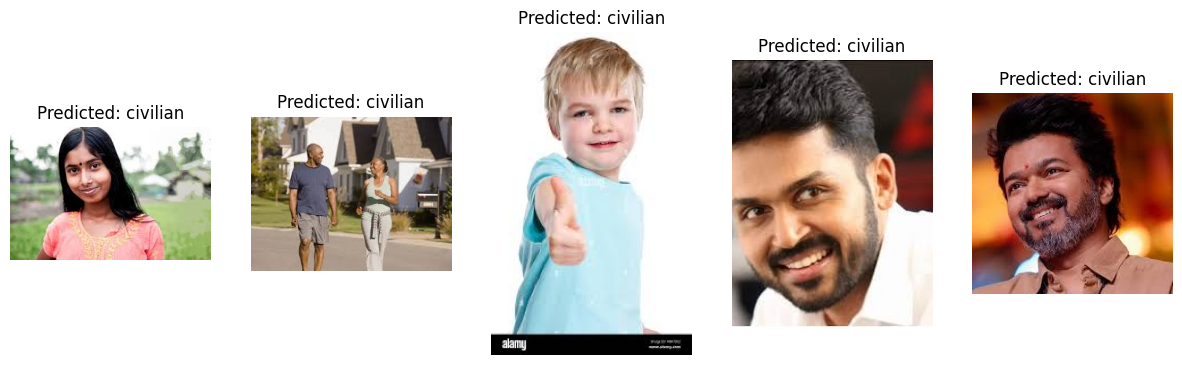

In [2]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from transformers import AutoImageProcessor, AutoModelForImageClassification

def load_dataset(path, category):
    images, labels = [], []
    img_paths = glob(os.path.join(path, '**', '*.jpg'), recursive=True)
    img_paths.extend(glob(os.path.join(path, '**', '*.png'), recursive=True))
    
    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(category)
    return images, labels

class DefenceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # Augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_path = '/kaggle/input/defence-dataset/Dataset/Classification'

datasets = {
    "Day Animal": load_dataset(os.path.join(base_path, 'Day/animal'), 'animal'),
    "Day Civilian": load_dataset(os.path.join(base_path, 'Day/human/civilian'), 'civilian'),
    "Day Soldier": load_dataset(os.path.join(base_path, 'Day/human/soldier'), 'soldier'),
    "Night Animal": load_dataset(os.path.join(base_path, 'Night/animal'), 'animal')
}

train_images, train_labels = [], []
for images, labels in datasets.values():
    train_images.extend(images[:400])  # Increased to 400 images per category
    train_labels.extend(labels[:400])

print(f"Loaded {len(train_images)} images for training.")  # Confirm dataset loading

if not train_images:
    raise ValueError("No images found. Check dataset paths.")

# Visualizing some sample images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i])
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis("off")
plt.show()

dataset = DefenceDataset(train_images, train_labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model_name = "google/efficientnet-b0"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(
    model_name, 
    num_labels=3, 
    id2label={0: "animal", 1: "civilian", 2: "soldier"}, 
    label2id={"animal": 0, "civilian": 1, "soldier": 2},
    ignore_mismatched_sizes=True
)

def train_model(model, dataloader, epochs=50, lr=1e-5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-6, max_lr=1e-4, step_size_up=10, mode='triangular')
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.2)
    
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)
            labels = torch.tensor([model.config.label2id[label] for label in labels], dtype=torch.long).to(device)
            optimizer.zero_grad()
            outputs = model(images).logits
            loss = loss_fn(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()
            
            if batch_idx % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx} | Loss: {loss.item():.4f}")
        
        avg_loss = running_loss / len(dataloader)
        print(f"Epoch {epoch+1} completed. Avg Loss: {avg_loss:.4f}")
        
        if avg_loss < 0.1:
            print("Early stopping triggered. Training stopped.")
            break
    
    print("Training complete.")
    torch.save(model.state_dict(), "defence_efficientnet.pth")

def test_model(model, test_images):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()
    
    fig, axes = plt.subplots(1, len(test_images), figsize=(15, 5))
    for i, img in enumerate(test_images):
        transformed_img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(transformed_img).logits
            pred = torch.argmax(outputs, dim=1).item()
            pred_label = model.config.id2label[pred]
        
        axes[i].imshow(img)
        axes[i].set_title(f"Predicted: {pred_label}")
        axes[i].axis("off")
    plt.show()

train_model(model, dataloader)

# Select random images from the dataset to test
test_images = [train_images[i] for i in np.random.choice(len(train_images), 5, replace=False)]
test_model(model, test_images)


Civilian Images: 50
Soldier Images: 50


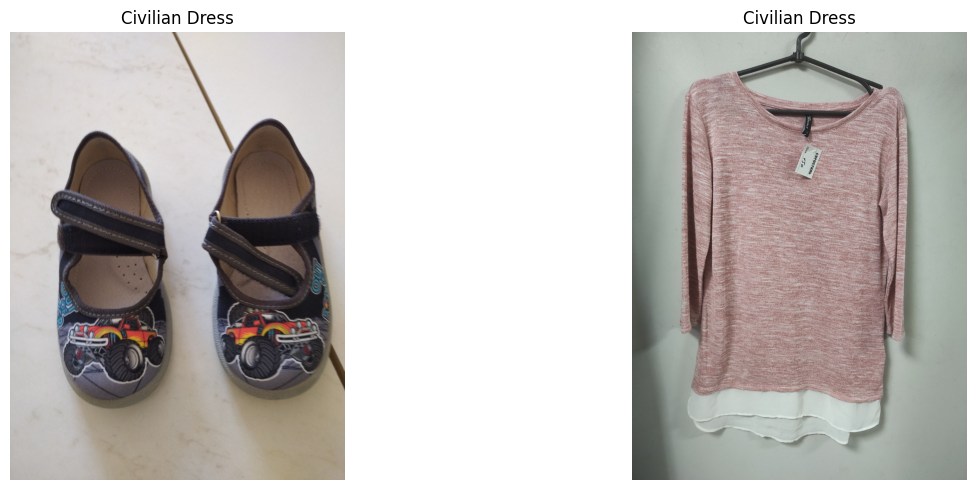

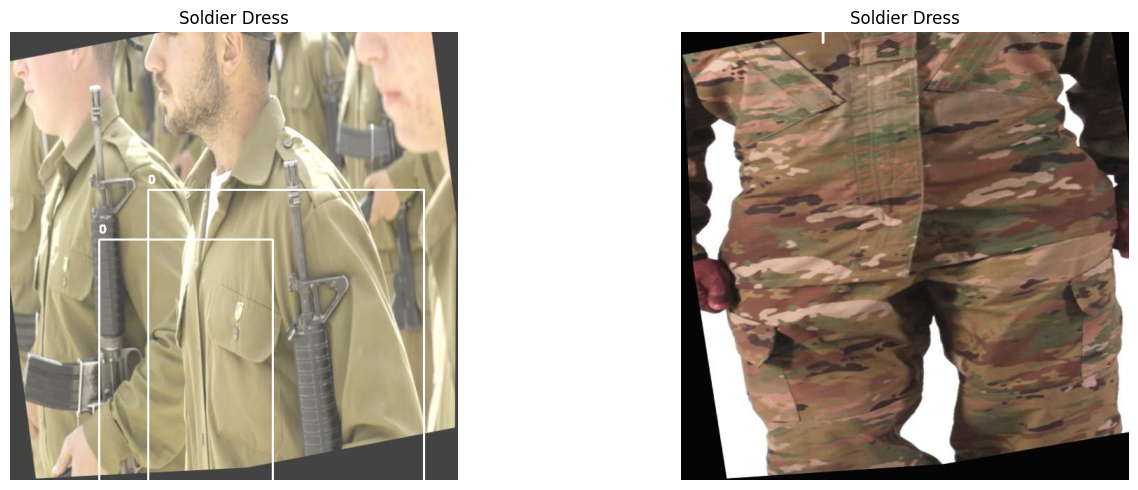

In [3]:
import os
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

def parse_txt(txt_path):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                class_name = parts[0]
                coords = [float(x) for x in parts[1:5]]
                boxes.append({'class': class_name, 'coords': coords})
    return boxes

def load_images_and_labels(image_path, label_path, category, max_images=100):
    images, labels = [], []
    img_paths = glob(os.path.join(image_path, '*.jpg')) + glob(os.path.join(image_path, '*.png'))
    img_paths = img_paths[:max_images]  # Limit the number of images to reduce memory usage
    
    for img_path in img_paths:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
            txt_path = os.path.join(label_path, os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt'))
            boxes = parse_txt(txt_path)
            labels.append(boxes if boxes else None)
    return images, labels

def draw_boxes(img, boxes):
    img_copy = img.copy()
    img_height, img_width = img.shape[:2]
    
    colors = {'civilian': (0, 255, 0), 'soldier': (0, 0, 255)}
    
    for box in boxes:
        coords = box['coords']
        class_name = box['class'].lower()
        color = colors.get(class_name, (255, 255, 255))
        
        x_center, y_center, width, height = coords
        if x_center <= 1.0:
            x_center *= img_width
            y_center *= img_height
            width *= img_width
            height *= img_height
        
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_copy, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_copy

def display_samples(images, labels, category, num_samples=3):
    if not images:
        print(f"No images found for {category}")
        return
    
    num_samples = min(num_samples, len(images))  # Ensure we don't select more than available images
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img = images[idx]
        if labels[idx]:
            img = draw_boxes(img, labels[idx])
        axes[i].imshow(img)
        axes[i].set_title(category)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

base_path = '/kaggle/input/defence-dataset/Dataset/dresses'

civilian_images, civilian_labels = load_images_and_labels(
    os.path.join(base_path, 'civilians/images_original'),
    os.path.join(base_path, 'civilians/images.csv'),
    'civilian',
    max_images=50  # Reduce memory usage
)

soldier_images, soldier_labels = load_images_and_labels(
    os.path.join(base_path, 'soldiers/images'),
    os.path.join(base_path, 'soldiers/labels'),
    'soldier',
    max_images=50  # Reduce memory usage
)

print(f"Civilian Images: {len(civilian_images)}")
print(f"Soldier Images: {len(soldier_images)}")

display_samples(civilian_images, civilian_labels, "Civilian Dress", num_samples=2)
display_samples(soldier_images, soldier_labels, "Soldier Dress", num_samples=2)


In [4]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.7/914.7 kB 13.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install -U "ray[tune]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 2.5 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from glob import glob
from tqdm import tqdm
from ultralytics import YOLO
import random
import shutil
import matplotlib.pyplot as plt
from PIL import Image

# Define paths
CIVILIAN_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/civilians/images_original"
SOLDIER_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/soldiers/images"
DATASET_PATH = "/kaggle/working/dataset"
IMAGE_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")
TRAIN_PATH = os.path.join(IMAGE_PATH, "train")
VAL_PATH = os.path.join(IMAGE_PATH, "val")
TRAIN_LABELS_PATH = os.path.join(LABELS_PATH, "train")
VAL_LABELS_PATH = os.path.join(LABELS_PATH, "val")
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")
MODEL_SAVE_PATH = "/kaggle/working/yolo_model.pt"

# Load images
civilian_images = glob(os.path.join(CIVILIAN_PATH, "*.jpg"))
soldier_images = glob(os.path.join(SOLDIER_PATH, "*.jpg"))
all_images = civilian_images + soldier_images

# Create dataset structure
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(VAL_PATH, exist_ok=True)
os.makedirs(TRAIN_LABELS_PATH, exist_ok=True)
os.makedirs(VAL_LABELS_PATH, exist_ok=True)

# Split data into train and val
random.shuffle(all_images)
split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

for img in train_images:
    shutil.copy(img, TRAIN_PATH)

for img in val_images:
    shutil.copy(img, VAL_PATH)

# Transform for feature extraction
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load EfficientNet-B0 for feature extraction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).to(device)
model.eval()

# Extract features
features = []
image_paths = []

print("Extracting features...")
for img_path in tqdm(all_images):
    img = Image.open(img_path).convert("RGB")  # Convert to PIL image
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feature = model(img).squeeze().cpu().numpy()

    features.append(feature)
    image_paths.append(img_path)

features = np.array(features)

# Apply K-Means Clustering
print("Clustering images into 2 groups...")
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels = kmeans.fit_predict(features)

# Save labels as YOLO format
for img_path, label in zip(image_paths, labels):
    base_name = os.path.basename(img_path)
    label_file = os.path.join(TRAIN_LABELS_PATH if img_path in train_images else VAL_LABELS_PATH, base_name.replace(".jpg", ".txt"))
    with open(label_file, "w") as f:
        f.write(f"{label} 0.5 0.5 1.0 1.0\n")  # Assign full bounding box

print("Labels generated successfully!")

# Create data.yaml
data_yaml = f"""
train: {TRAIN_PATH}
val: {VAL_PATH}
nc: 2
names: ["civilian", "soldier"]
"""

with open(DATA_YAML, "w") as f:
    f.write(data_yaml)

# Train YOLO model
print("Training YOLOv8 model...")
model = YOLO("yolov8n.pt")  # Using pre-trained YOLOv8
model.train(data=DATA_YAML, epochs=5, batch=16, imgsz=640)

# Save trained model
model.export(format="torchscript")  # Save in TorchScript format
print(f"Model saved at {MODEL_SAVE_PATH}")



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s] 


Extracting features...


100%|██████████| 5891/5891 [15:33<00:00,  6.31it/s]


Clustering images into 2 groups...
Labels generated successfully!
Training YOLOv8 model...


...


5 epochs completed in 3.844 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.74 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 37/37 [03:36<00:00,  5.86s/it]


                   all       1179       1179      0.924      0.913       0.96       0.96
              civilian        209        209      0.889      0.846      0.931      0.931
               soldier        970        970       0.96       0.98      0.989      0.989


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.1ms preprocess, 126.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train
Ultralytics 8.3.74 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.9 MB)

TorchScript: starting export with torch 2.5.1+cu121...
TorchScript: export success ✅ 2.6s, saved as 'runs/detect/train/weights/best.torchscript' (11.9 MB)

Export complete (3.2s)
Results saved to /kaggle/working/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.torchscript imgsz=640  
Validate:        yolo val task=detect model=runs/detect/train/weights/best.torchscript imgsz=640 data=/kaggle/working/dataset/data.yaml  
Visualize:       https://netron.app
Model saved at /kaggle/working/yolo_model.pt


Processing Speed: {'preprocess': 3.8971900939941406, 'inference': 123.10171127319336, 'postprocess': 1.2094974517822266}


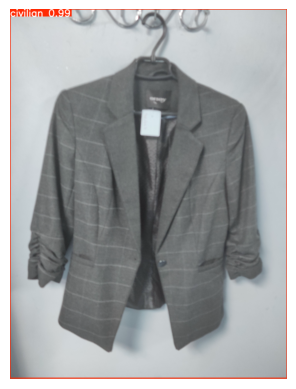

Processing Speed: {'preprocess': 2.818584442138672, 'inference': 104.31408882141113, 'postprocess': 1.0981559753417969}


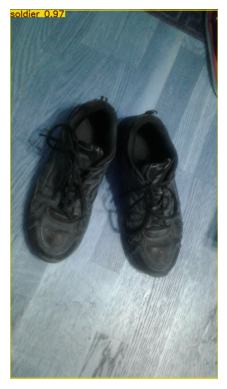

Processing Speed: {'preprocess': 2.304553985595703, 'inference': 152.2986888885498, 'postprocess': 1.1980533599853516}


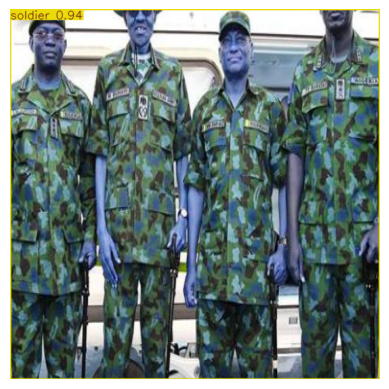

Processing Speed: {'preprocess': 2.1414756774902344, 'inference': 147.60375022888184, 'postprocess': 1.1997222900390625}


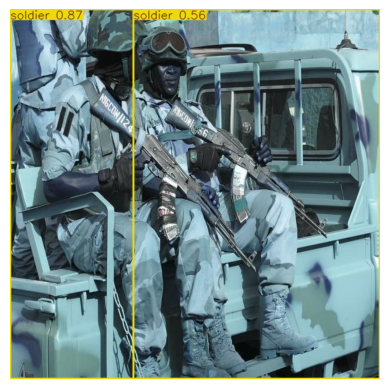

In [14]:
import torch
import random
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the trained YOLO model
MODEL_SAVE_PATH = "/kaggle/working/runs/detect/train/weights/best.pt"
model = YOLO(MODEL_SAVE_PATH)

# Define image directories
CIVILIAN_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/civilians/images_original"
SOLDIER_PATH = "/kaggle/input/defence-dataset/Dataset/dresses/soldiers/images"

# Get list of images
civilian_images = glob.glob(f"{CIVILIAN_PATH}/*.jpg")
soldier_images = glob.glob(f"{SOLDIER_PATH}/*.jpg")

# Randomly select images from both categories
test_images = random.sample(civilian_images, min(2, len(civilian_images))) + \
              random.sample(soldier_images, min(2, len(soldier_images)))

# Define label mapping (flipping the labels)
label_mapping = {0: "soldier", 1: "civilian"}  # Swap civilian ↔ soldier

for img in test_images:
    results = model(img, verbose=False)
    
    # Modify results by flipping labels
    for result in results:
        if result.boxes is not None and len(result.boxes) > 0:
            new_boxes_data = result.boxes.data.clone()
            new_boxes_data[:, 5] = torch.tensor(
                [1 if cls == 0 else 0 for cls in result.boxes.cls.tolist()],
                dtype=result.boxes.cls.dtype,
                device=result.boxes.cls.device
            )
            result.boxes.data = new_boxes_data
    
    # Display speed and output image
    print(f"Processing Speed: {result.speed}")
    plt.imshow(results[0].plot())
    plt.axis("off")
    plt.show()


Civilian Images: 81
Soldier Images: 74


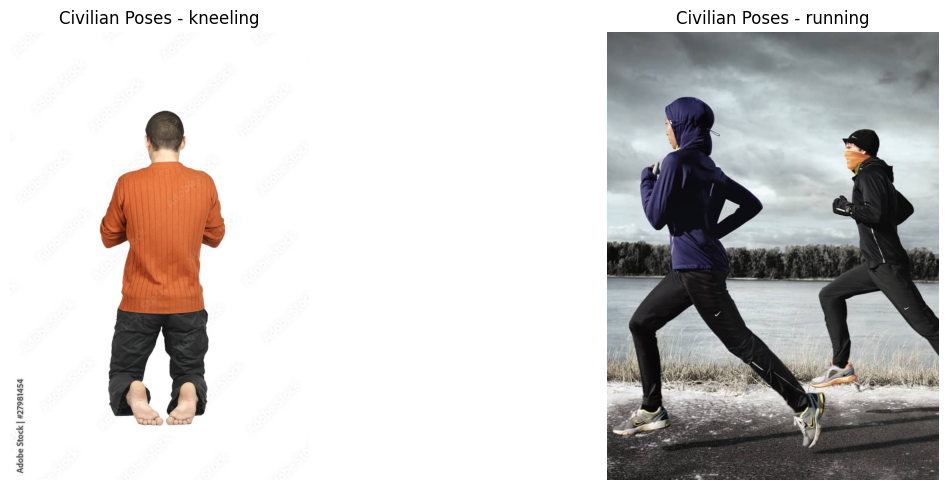

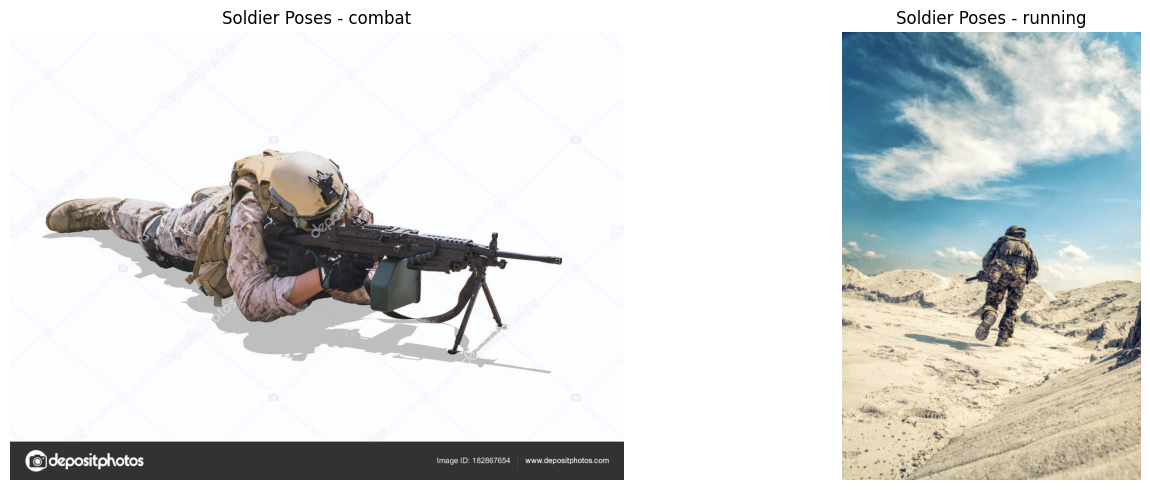

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from glob import glob

def load_annotations(annotation_path):
    with open(annotation_path, 'r') as f:
        return json.load(f)

def load_images_and_labels(image_folders, annotation_data, category, max_images=20):
    images, labels, poses = [], [], []
    
    for folder in image_folders:
        pose_name = os.path.basename(folder)  # Extract pose name from folder structure
        img_paths = glob(os.path.join(folder, '*.jpg')) + glob(os.path.join(folder, '*.png'))
        img_paths = img_paths[:max_images]  # Limit the number of images to reduce memory usage
        
        for img_path in img_paths:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                poses.append(pose_name)  # Store pose name
                
                img_name = os.path.basename(img_path)
                boxes = annotation_data.get(img_name, [])
                labels.append(boxes if boxes else None)
    
    return images, labels, poses

def draw_boxes(img, boxes, pose, override_label=None):
    img_copy = img.copy()
    img_height, img_width = img.shape[:2]
    
    colors = {'civilian': (0, 255, 0), 'soldier': (0, 0, 255), 'combat': (255, 0, 0)}
    
    for box in boxes:
        coords = box['coords']
        class_name = override_label if override_label else box['class'].lower()
        color = colors.get(class_name, (255, 255, 255))
        
        x_center, y_center, width, height = coords
        if x_center <= 1.0:
            x_center *= img_width
            y_center *= img_height
            width *= img_width
            height *= img_height
        
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)
        
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
        label_text = f"{class_name} ({pose})"
        cv2.putText(img_copy, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return img_copy

def display_samples(images, labels, poses, category, override_label=None, num_samples=3):
    if not images:
        print(f"No images found for {category}")
        return
    
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img = images[idx]
        pose = poses[idx]
        if labels[idx]:
            img = draw_boxes(img, labels[idx], pose, override_label)
        axes[i].imshow(img)
        axes[i].set_title(f"{category} - {pose}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

base_path = '/kaggle/input/defence-dataset/Dataset/poses'
annotation_path = os.path.join(base_path, 'annotations/pose_annotations.json')
annotations = load_annotations(annotation_path)

civilian_folders = [
    os.path.join(base_path, 'civilian/kneeling'),
    os.path.join(base_path, 'civilian/running'),
    os.path.join(base_path, 'civilian/sitting'),
    os.path.join(base_path, 'civilian/standing'),
    os.path.join(base_path, 'civilian/walking')
]

soldier_folders = [
    os.path.join(base_path, 'soldier/combat'),
    os.path.join(base_path, 'soldier/kneeling'),
    os.path.join(base_path, 'soldier/running'),
    os.path.join(base_path, 'soldier/standing')
]

civilian_images, civilian_labels, civilian_poses = load_images_and_labels(civilian_folders, annotations, 'civilian', max_images=20)
soldier_images, soldier_labels, soldier_poses = load_images_and_labels(soldier_folders, annotations, 'soldier', max_images=20)

print(f"Civilian Images: {len(civilian_images)}")
print(f"Soldier Images: {len(soldier_images)}")

display_samples(civilian_images, civilian_labels, civilian_poses, "Civilian Poses", num_samples=2)
display_samples(soldier_images, soldier_labels, soldier_poses, "Soldier Poses", override_label="combat" if 'combat' in soldier_folders else None, num_samples=2)


Readable Images: 318
Unreadable Images: 64


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s] 


Epoch 1, Loss: 0.1888, Accuracy: 0.9407
Epoch 2, Loss: 0.0024, Accuracy: 1.0000
Epoch 3, Loss: 0.0002, Accuracy: 1.0000
Epoch 4, Loss: 0.0001, Accuracy: 1.0000
Epoch 5, Loss: 0.0000, Accuracy: 1.0000
Epoch 6, Loss: 0.0000, Accuracy: 1.0000
Epoch 7, Loss: 0.0000, Accuracy: 1.0000
Epoch 8, Loss: 0.0000, Accuracy: 1.0000
Epoch 9, Loss: 0.0000, Accuracy: 1.0000
Epoch 10, Loss: 0.0000, Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        65

    accuracy                           1.00        65
   macro avg       1.00      1.00      1.00        65
weighted avg       1.00      1.00      1.00        65

Accuracy: 1.0


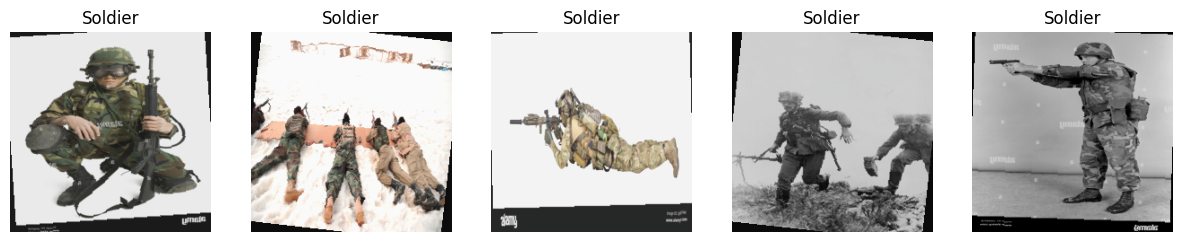

In [16]:
import os
import cv2
import json
import torch
import random
import numpy as np
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image
import imghdr

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load annotations
def load_annotations(annotation_path):
    with open(annotation_path, 'r') as f:
        return json.load(f)

# Custom Dataset Class
class ActionDataset(Dataset):
    def __init__(self, image_paths, annotations, transform=None):
        self.image_paths = image_paths
        self.annotations = annotations
        self.transform = transform
        self.readable_images = []
        self.unreadable_count = 0
        
        for img_path in image_paths:
            if imghdr.what(img_path) is None:
                self.unreadable_count += 1
            else:
                self.readable_images.append(img_path)

    def __len__(self):
        return len(self.readable_images)

    def __getitem__(self, idx):
        img_path = self.readable_images[idx]
        try:
            img = Image.open(img_path).convert("RGB")
            img = np.array(img)
        except Exception as e:
            return None, None
        
        img_name = os.path.basename(img_path)
        label = self.annotations.get(img_name, {'class': 'civilian'})['class']
        label = 1 if label.lower() == 'soldier' else 0
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# Data Paths
base_path = '/kaggle/input/defence-dataset/Dataset/poses'
annotation_path = os.path.join(base_path, 'annotations/pose_annotations.json')
annotations = load_annotations(annotation_path)

image_folders = [
    os.path.join(base_path, 'civilian/kneeling'),
    os.path.join(base_path, 'civilian/running'),
    os.path.join(base_path, 'civilian/sitting'),
    os.path.join(base_path, 'civilian/standing'),
    os.path.join(base_path, 'civilian/walking'),
    os.path.join(base_path, 'soldier/combat'),
    os.path.join(base_path, 'soldier/kneeling'),
    os.path.join(base_path, 'soldier/running'),
    os.path.join(base_path, 'soldier/standing')
]

# Collect image paths
image_paths = []
for folder in image_folders:
    image_paths.extend([os.path.join(folder, img) for img in os.listdir(folder) if img.endswith(('jpg', 'png'))])

# Train-Test Split
train_paths, test_paths = train_test_split(image_paths, test_size=0.2, random_state=42)

# Data Transformations
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Datasets and Loaders
train_dataset = ActionDataset(train_paths, annotations, transform=transform)
test_dataset = ActionDataset(test_paths, annotations, transform=transform)

print(f"Readable Images: {len(train_dataset.readable_images) + len(test_dataset.readable_images)}")
print(f"Unreadable Images: {train_dataset.unreadable_count + test_dataset.unreadable_count}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model (ResNet50 with Custom Classifier)
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2)
)
model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Training Function
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    best_acc = 0.0
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        acc = correct / total
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "pose_model.pth")
def test_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    sample_images = []
    sample_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            
            sample_images.extend(images.cpu().numpy()[:5])  # Store first 5 images
            sample_preds.extend(predicted.cpu().numpy()[:5])
    
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    
    # Visualize Test Results
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i in range(5):
        img = np.transpose(sample_images[i], (1, 2, 0))
        img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        label = "Civilian" if sample_preds[i] == 1 else "Soldier"
        axes[i].imshow(img)
        axes[i].set_title(label)
        axes[i].axis("off")
    plt.show()



# Train and Evaluate
train_model(model, train_loader, criterion, optimizer, epochs=10)
model.load_state_dict(torch.load("pose_model.pth"))
test_model(model, test_loader)
